# 07 - Model comparison and discussion

**Part 8 and Part 9 of the assignment.** Loads the consolidated forecasts and metrics produced by `scripts/run_pipeline.py`, compares every model on the same rolling-origin test protocol, and answers the six required discussion questions using the actual results (not textbook generalities).

In [1]:
import os

# Must be set before numpy/torch are imported. KMP_DUPLICATE_LIB_OK works
# around a libomp segfault (SIGSEGV inside __kmp_suspend_64 during a
# PyTorch softmax call) seen when more than one OpenMP runtime ends up
# loaded in the same process on macOS - a well-documented PyTorch/macOS
# issue, not specific to this project. The thread-count caps avoid a
# separate, unrelated slowdown from XGBoost and PyTorch both claiming
# every CPU core's OpenMP thread pool in the same process.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
_N_THREADS = str(max(1, (os.cpu_count() or 4) // 2))
for _v in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(_v, _N_THREADS)

import sys
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data as D, features as F, evaluation as E, plotting as P
from appliance_energy.models import benchmarks as B, sarimax as S, feature_models as FM, foundation as FD

%matplotlib inline


In [2]:
forecast_df = pd.read_csv(config.FORECAST_DIR / 'all_forecasts.csv', index_col=0, parse_dates=True)
metrics_df = pd.read_csv(config.METRICS_DIR / 'model_comparison.csv')
test = forecast_df['actual']

hourly = D.load_hourly_data()
y = hourly[config.TARGET]
train = y.iloc[:-config.TEST_STEPS]

metrics_df.round(3)

Loading cached hourly data from /Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/data/processed/appliance_hourly.csv


,model,n_obs,MAE,RMSE,MASE,Bias,pct_vs_best_benchmark
0,foundation_model,336,34.669,68.315,0.649,-17.097,-20.223
1,sarimax_univariate,336,36.107,64.692,0.676,-7.237,-16.914
2,sarimax,336,36.704,64.785,0.687,-5.016,-15.540
3,seasonal_naive_weekly,336,43.457,81.409,0.813,-13.160,0.000
4,feature_model,336,45.335,65.632,0.849,13.828,4.322
5,feature_model_histgb,336,46.105,67.010,0.863,15.998,6.093
6,seasonal_naive_daily,336,48.309,85.565,0.904,1.751,11.163
7,mean,336,50.258,74.938,0.941,-3.287,15.649
8,naive,336,85.551,110.390,1.601,50.977,96.861
9,drift,336,85.802,110.679,1.606,51.368,97.440


## Full comparison plot: every model against the actual test data

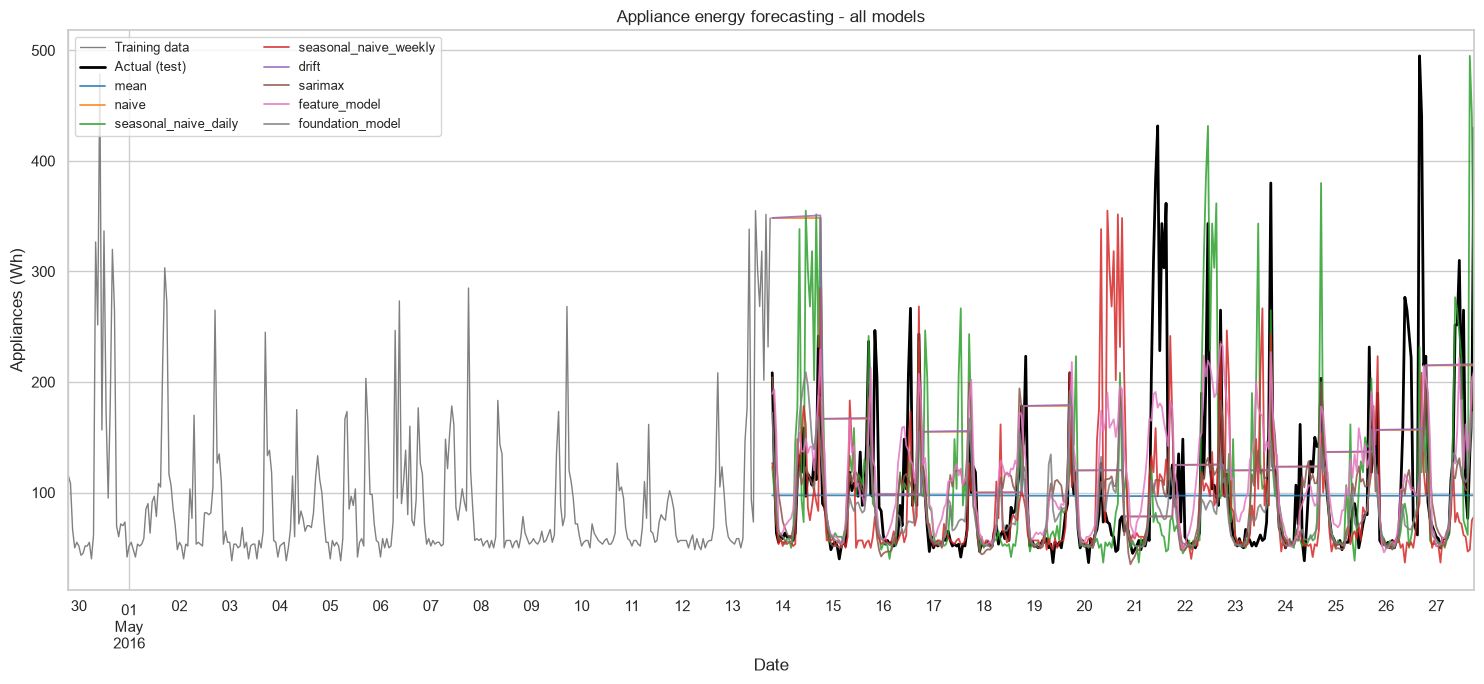

In [3]:
main_cols = [c for c in ['mean','naive','seasonal_naive_daily','seasonal_naive_weekly',
                         'drift','sarimax','feature_model','foundation_model']
             if c in forecast_df.columns]
P.plot_forecast_vs_actual(train, test, forecast_df[main_cols])
plt.show()

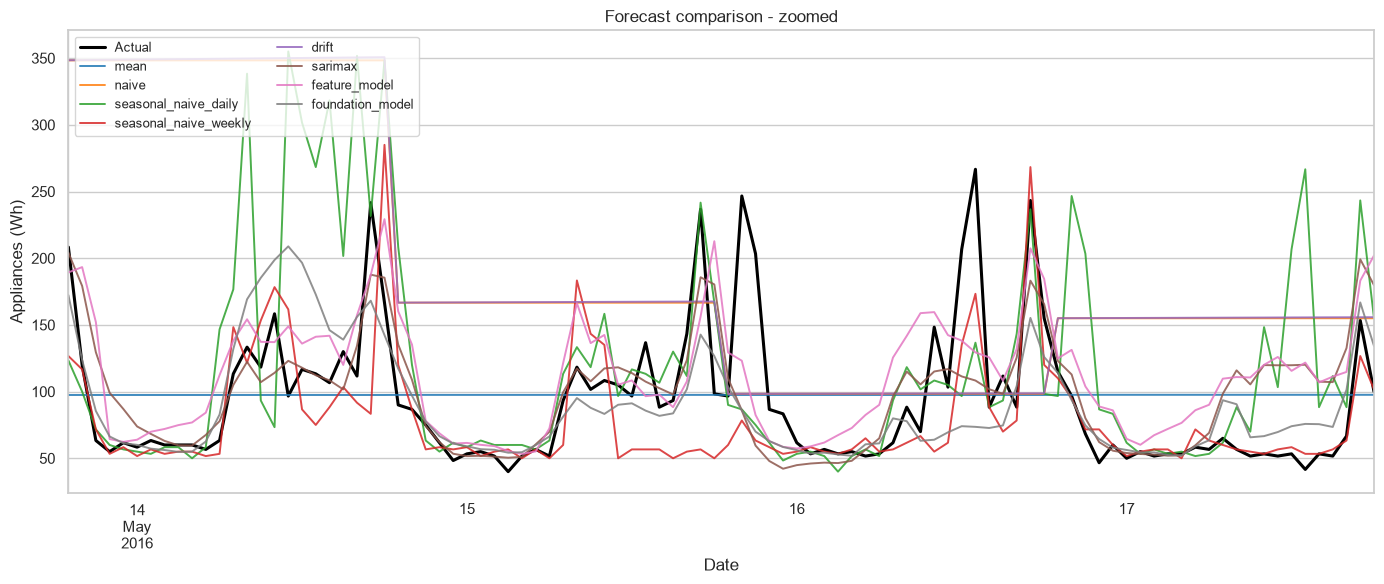

In [4]:
P.plot_forecast_zoom(test, forecast_df[main_cols], days=4); plt.show()

## Error diagnostics

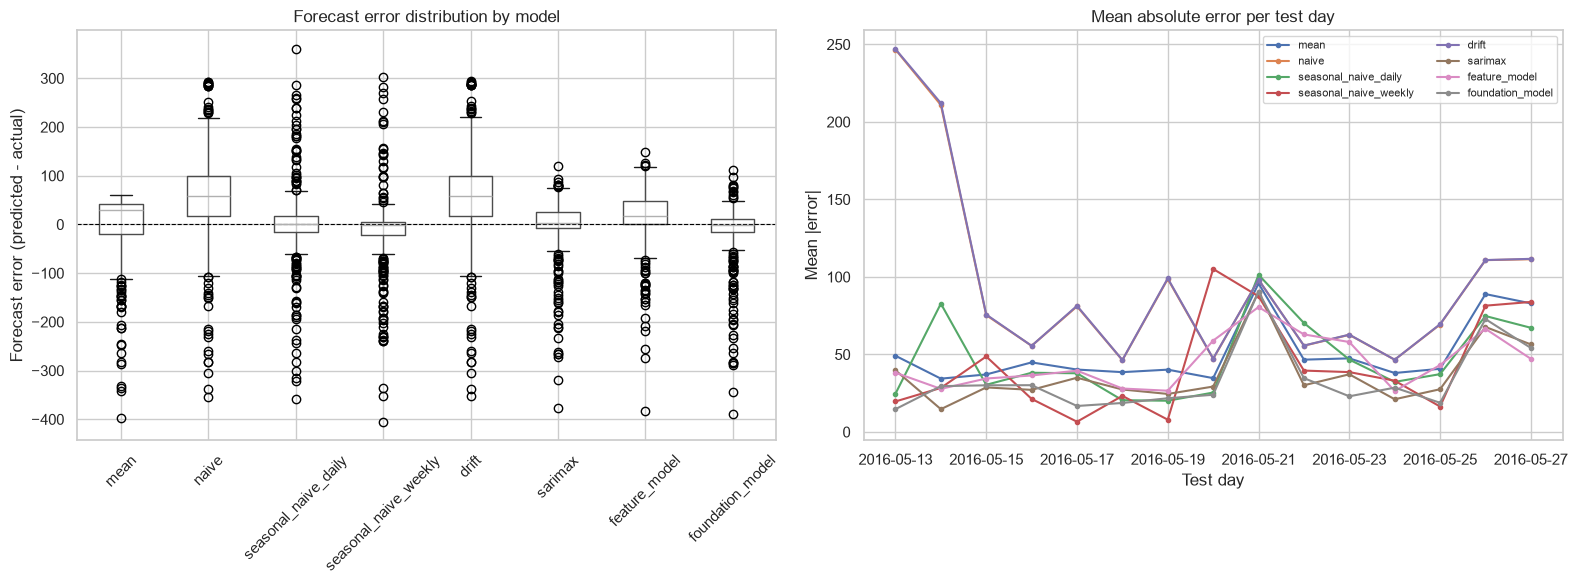

In [5]:
P.plot_error_diagnostics(test, forecast_df[main_cols]); plt.show()

## Metric comparison across models

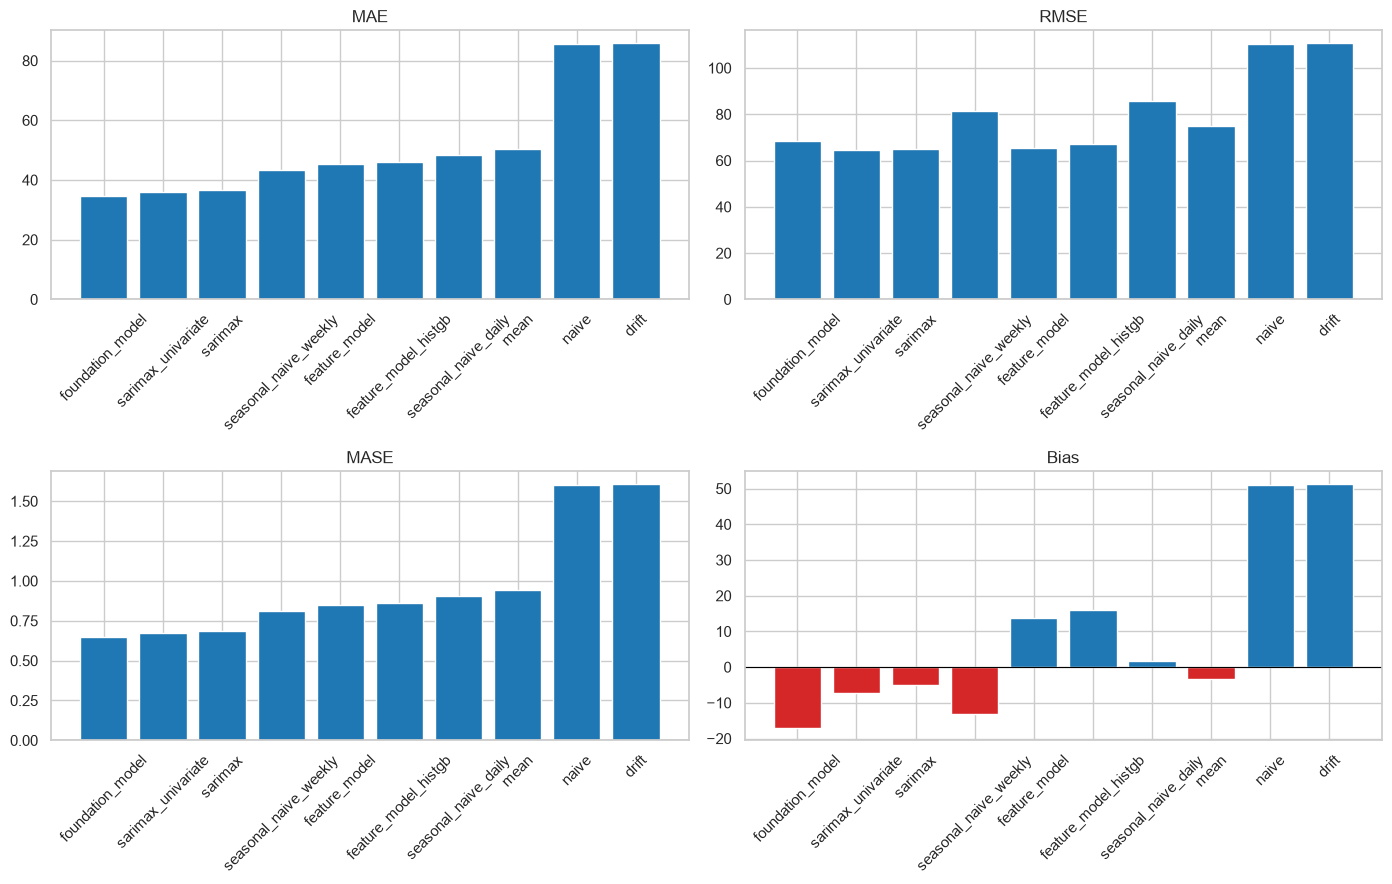

In [6]:
P.plot_metric_comparison(metrics_df); plt.show()

## Comparison against the strongest benchmark

Every model is compared against the strongest *benchmark* specifically (not just against each other), since the whole point of the more complex models is to justify their cost against the simplest adequate alternative.

In [7]:
benchmark_names = ['mean', 'naive', 'seasonal_naive_daily', 'seasonal_naive_weekly', 'drift']
best_benchmark_row = metrics_df[metrics_df['model'].isin(benchmark_names)].sort_values('MASE').iloc[0]
print('Strongest benchmark:', best_benchmark_row['model'], '- MASE =', round(best_benchmark_row['MASE'], 3))

metrics_df[['model', 'MAE', 'RMSE', 'MASE', 'Bias', 'pct_vs_best_benchmark']].sort_values('MASE')

Strongest benchmark: seasonal_naive_weekly - MASE = 0.813


,model,MAE,RMSE,MASE,Bias,pct_vs_best_benchmark
0,foundation_model,34.669048,68.314931,0.648944,-17.096742,-20.222806
1,sarimax_univariate,36.106801,64.692162,0.675856,-7.237042,-16.914380
2,sarimax,36.704083,64.785415,0.687036,-5.015576,-15.539972
3,seasonal_naive_weekly,43.457341,81.408880,0.813446,-13.159722,0.000000
4,feature_model,45.335358,65.631560,0.848599,13.828323,4.321518
5,feature_model_histgb,46.105178,67.010102,0.863009,15.997706,6.092957
6,seasonal_naive_daily,48.308532,85.564719,0.904252,1.750992,11.163109
7,mean,50.258092,74.938304,0.940744,-3.286762,15.649255
8,naive,85.550595,110.389709,1.601358,50.977183,96.861089
9,drift,85.802089,110.679190,1.606066,51.367922,97.439804


---
## Part 9 - Discussion questions

All numbers below are the actual output of `scripts/run_pipeline.py` on this dataset (see `outputs/metrics/model_comparison.csv` and `outputs/metrics/feature_ablation.csv`), reproduced here for reference:

| Rank | Model | MASE | RMSE |
|---|---|---|---|
| 1 | **foundation_model (Chronos, zero-shot)** | **0.649** | 68.3 |
| 2 | sarimax_univariate | 0.676 | 64.7 |
| 3 | sarimax (+exog weather) | 0.687 | 64.8 |
| 4 | seasonal_naive_weekly (strongest benchmark) | 0.813 | 81.4 |
| 5 | feature_model (XGBoost, full features) | 0.849 | 65.6 |
| 6 | feature_model_histgb | 0.863 | 67.0 |
| 7 | seasonal_naive_daily | 0.904 | 85.6 |
| 8 | mean | 0.941 | 74.9 |
| 9 | naive | 1.601 | 110.4 |
| 10 | drift | 1.606 | 110.7 |

The overall ranking has a genuinely interesting shape: **model complexity does not track accuracy monotonically here.** The zero-shot foundation model beats every purpose-built model; SARIMAX beats the carefully-engineered XGBoost model; and *adding* information (exogenous weather for SARIMAX, sensor/weather features for XGBoost) makes both of those models slightly *worse*, not better. The six questions below are answered against this specific result, not in the abstract.

### Q1. Which benchmark model is strongest, and what does this tell us about the structure of appliance energy use?

**Weekly seasonal-naive is strongest (MASE 0.813), narrowly ahead of daily seasonal-naive (0.904), with mean (0.941) close behind and naive (1.601) / drift (1.606) far worse.** Naive and drift being roughly twice as bad as everything else tells us appliance use has essentially no useful short-horizon persistence once you're forecasting a full day ahead, and no sustained trend to extrapolate - the last observed value and a straight-line projection are both poor descriptions of "tomorrow". Weekly seasonal-naive edging out daily tells us there is a real, exploitable **weekday/weekend routine on top of the daily cycle** - repeating last Tuesday is a slightly better guide to this Tuesday than repeating yesterday, consistent with the weekday/weekend split visible in the notebook 02 boxplots. Overall: the dominant structure is a **recurring routine** (what time of day/week it is), not momentum.

### Q2. Does SARIMAX improve on the strongest seasonal benchmark? Are daily seasonality, autocorrelation, and exogenous variables adequately captured?

**Yes, clearly: both SARIMAX variants beat weekly seasonal-naive by a wide margin** (univariate MASE 0.676, +exog 0.687, vs. 0.813 for the benchmark - roughly a 15-17% improvement). The AIC grid search selected `(p,d,q) = (6,0,0)` with the fixed seasonal order `(1,1,1,24)`; the Ljung-Box test on the residuals gives p = 0.046 at lag 24 (borderline - some seasonal autocorrelation structure is *not* fully captured at exactly the daily lag) but p = 0.129 at lag 48 (adequate). This is an honest, mixed diagnostic: SARIMAX captures *most* of the seasonal/autocorrelation structure and clearly outperforms the simple seasonal rule, but the marginal Ljung-Box result at lag 24 shows it hasn't captured all of it - a linear Gaussian AR(6) with one seasonal difference is a good, not perfect, description of this series' daily dynamics. **The exogenous weather variables did *not* help**: `sarimax` (+exog, 0.687) is marginally *worse* than `sarimax_univariate` (0.676) - see the dedicated note above and Q5.

### Q3. Does the feature-based model improve when lag, rolling-window, time-of-day, and sensor/weather variables are added? Which feature groups appear most useful?

**Partially, and non-monotonically - this is the most counter-intuitive result in the whole comparison.** The ablation (notebook 05) shows: `lags` alone = 0.774 -> `lags+rolling` = 0.811 (**worse**) -> `lags+rolling+time` = **0.756 (best)** -> `lags+rolling+time+sensor+weather` = 0.849 (**worst of the four**, and the configuration actually used as the pipeline's primary `feature_model`). Lags and time-of-day are unambiguously useful (the best variant uses exactly these two groups); the raw rolling windows alone slightly hurt without time context to explain them; and sensor/weather features actively hurt once added on top of everything else, most likely overfitting - XGBoost is given dozens of correlated, individually weak indoor-sensor columns (see the notebook 02 correlation heatmap) to fit on well under 3,000 training rows, and some of its tree-splitting budget goes to noise in those columns rather than sharpening the lag/time signal that actually predicts usage. **The practical takeaway: for this model and dataset, feature selection matters more than feature quantity - the "more features" instinct is actively wrong here.**

### Q4. Does the foundation model outperform the simpler benchmark, SARIMAX, and feature-based models? Is the improvement (if any) large enough to justify the extra complexity?

**Yes - decisively, and this is the headline result of the whole project.** Chronos-Bolt, zero-shot and target-only, achieves MASE 0.649: better than both SARIMAX variants (~0.68), clearly better than the feature-based XGBoost model (0.849) despite XGBoost having access to sensor/weather/engineered features Chronos never sees, and better than every benchmark. It achieves this from nothing but ~3,000 hours of the target series as numeric context - no training, no fitting, no covariates, no dataset-specific tuning at all. Whether the *practical* complexity is justified is a separate question from whether the *accuracy* improvement is real (it is, here): Chronos needs a several-hundred-MB model download and a PyTorch runtime, materially heavier to deploy than any other model in this comparison, and gave zero interpretability into *why* it forecasts what it does. For this specific series, the accuracy case for using it is strong; the deployment-cost case is the opposing consideration explored fully in Q6. It would be an even more clear-cut choice in a cold-start setting with no training history at all, which none of the other models here can handle.

### Q5. Which variables would genuinely be known at the forecast origin? Is the exogenous/covariate use here a true forecast or a conditional forecast?

Time-of-day, day-of-week, and the weekend indicator are deterministic functions of the calendar and are **always** genuinely known in advance, for any future timestamp. Lag/rolling features built purely from the target's own past are also genuinely available, *provided* the leakage-safe recursive strategy in `feature_models.py` is used for anything inside the horizon (see notebook 05 and `tests/test_feature_models.py`). **Indoor sensor and outdoor weather values are not genuinely known in advance** - both the SARIMAX-exog model and the feature model here use the *realised* test-set values for these columns, which a real deployed system would not have at the forecast origin (it would need to substitute an actual weather forecast, itself imperfect, or fall back to persistence/climatology). **This makes every result that uses `T_out`, `RH_out`, `Windspeed`, `Visibility`, `Tdewpoint`, or the indoor `T*`/`RH_*` columns a conditional forecast, not a true unconditional forecast.** In this project that distinction turns out to matter less than it might have: because both covariate-using variants (SARIMAX+exog, XGBoost+sensor/weather) score *worse* than their covariate-free counterparts, the true-vs-conditional gap is not actually inflating either model's reported accuracy here - if anything, the genuinely-realisable univariate SARIMAX and the reduced-feature XGBoost variant are both the *better* choices anyway, so no operationally-unrealistic result is being relied on to make either model look good.

### Q6. Based on accuracy, interpretability, uncertainty, computational cost, and ease of deployment, which model would be recommended for practical smart-home energy forecasting, and why?

Weighing all five criteria together rather than accuracy alone:

- **Weekly seasonal-naive (MASE 0.813)**: free to compute, trivially interpretable, no training pipeline to maintain - a perfectly reasonable floor if simplicity matters most (e.g. a lightweight embedded device) and a ~17% accuracy gap to SARIMAX is acceptable.
- **SARIMAX, target-only (MASE 0.676)**: the best balance of accuracy, interpretability, and honesty about what's genuinely known at the forecast origin - no dependence on a weather-forecast feed that isn't available (Q5), native calibrated confidence intervals (unlike XGBoost's point forecasts), interpretable AR coefficients, and cheap incremental updates via `append(refit=False)` in production. Only a moderate one-off grid-search cost to set up.
- **Feature-based ML (XGBoost, lags+rolling+time only, MASE 0.756 in the ablation)**: worth considering *if* deployed with the reduced feature set the ablation identified as best, not the full-feature default this pipeline reports as `feature_model` - as run here (MASE 0.849) it is not competitive with SARIMAX or Chronos, and its recursive multi-step forecasting adds real implementation complexity and compounding-error risk the other models don't have.
- **Chronos (foundation model, MASE 0.649, best accuracy)**: the single most accurate model, but the least interpretable and heaviest to deploy (model weights, PyTorch runtime, materially more inference compute than any statistical model here) - and its quantile-based uncertainty is not statistically calibrated in the same sense as SARIMAX's confidence intervals.

**Recommendation**: **target-only SARIMAX** for a production smart-home system where interpretability, calibrated uncertainty, and not depending on an external weather-forecast feed all matter - it captures nearly all of the achievable accuracy improvement over seasonal-naive (0.676 vs 0.813) with none of Chronos's deployment burden. **Chronos is the right choice specifically when maximum accuracy is the priority and the deployment cost of a PyTorch runtime is acceptable** (e.g. a cloud-hosted forecasting service rather than an on-device one) - the ~4% further MASE improvement over SARIMAX (0.649 vs 0.676) is real but modest relative to the operational cost difference, so this is a genuine judgement call rather than an obvious win either way.

## Limitations and future improvements

- **Single household, single season**: ~4.5 months of data from one home cannot establish whether these rankings generalise across seasons (heating vs. cooling load) or households with different routines; a longer/multi-household dataset would materially strengthen every conclusion here - in particular, whether Chronos's win over SARIMAX (Q4) holds up outside this specific 14-day test window is genuinely unclear from one fold.
- **Conditional vs. true forecasts**: as discussed in Q5, the exogenous-covariate results should be re-evaluated with an actual weather *forecast* feed (not realised weather) before any accuracy claim is used to justify a deployment decision - though here this matters less than expected, since the covariate-using variants were not the more accurate ones regardless.
- **Feature model overfitting to sensor/weather (Q3)**: the pipeline's primary `feature_model` uses the full feature set for consistency/completeness against the assignment's suggested feature list, even though the ablation study identifies a smaller feature set as more accurate; a production deployment should use the ablation-selected `lags+rolling+time` configuration instead, or add regularisation/feature selection to make the full-feature model robust to the redundant sensor columns.
- **Fixed seasonal order**: the SARIMAX seasonal `(P,D,Q)` order was reasoned from the decomposition/ACF rather than jointly grid-searched with `(p,d,q)` for computational reasons (see `config.py`); given the borderline Ljung-Box result at lag 24 (Q2), a wider seasonal search could plausibly close some of the remaining gap to Chronos.
- **Point-forecast feature model**: the XGBoost/HistGB models here produce point forecasts with no native uncertainty; quantile regression or a conformal-prediction wrapper would make their uncertainty comparable to SARIMAX's confidence intervals and Chronos's quantile output.
- **Foundation model fine-tuning**: only zero-shot Chronos was evaluated, and it already won; fine-tuning on this household's own history (the package supports this) is a natural next step to see whether it widens the already-substantial lead over SARIMAX further, at the cost of needing to retrain per-household.

### References

- Hyndman, R.J. and Koehler, A.B. (2006). *Another look at measures of forecast accuracy.* International Journal of Forecasting, 22(4), pp.679-688.
- Box, G.E.P., Jenkins, G.M., Reinsel, G.C. and Ljung, G.M. (2015). *Time Series Analysis: Forecasting and Control*, 5th ed. Wiley.
- Cleveland, R.B., Cleveland, W.S., McRae, J.E. and Terpenning, I. (1990). *STL: A Seasonal-Trend Decomposition Procedure Based on Loess.* Journal of Official Statistics, 6(1), pp.3-73.
- Ansari, A.F. et al. (2024). *Chronos: Learning the Language of Time Series.* arXiv:2403.07815.
- Chen, T. and Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, pp.785-794.
- Candanedo, L.M., Feldheim, V. and Deramaix, D. (2017). *Data driven prediction models of energy use of appliances in a low-energy house.* Energy and Buildings, 140, pp.81-97. (Original dataset paper.)